# 📝 Time Series - Machine Temperature

## 🌟 Highlights 
From this project "Time Series - Machine Temperature", the highlights are addressed as:

## 🏭 Build Flow
- Import libraries
- Data cleaning & EDA
- Anomaly detection - XGBoost



### Import Libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import numpy as np
import plotly.express as px
import plotly.graph_objects as go

from itertools import product

from scipy.stats import boxcox
from statsmodels.tsa.seasonal import STL
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.stattools import acf
from statsmodels.tsa.stattools import pacf
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.graphics.tsaplots import plot_pacf
from statsmodels.tsa.arima.model import ARIMA

from sklearn.ensemble import IsolationForest
from sklearn.metrics import classification_report, confusion_matrix, average_precision_score
from sklearn.inspection import permutation_importance
from xgboost import XGBClassifier

### Data cleaning & EDA
- Data collection frequency
- Data type correction
- Separate datetime for convinient filter
- Missing data
- Add label data into dataframe
- Visualization

In [2]:
file = r'D:\coding\2026\time_series_analysis\realKnownCause\realKnownCause\machine_temperature_system_failure.csv'

df = pd.read_csv(file)
df.head(10)

,timestamp,value
0,2013-12-02 21:15:00,73.967322
1,2013-12-02 21:20:00,74.935882
2,2013-12-02 21:25:00,76.124162
3,2013-12-02 21:30:00,78.140707
4,2013-12-02 21:35:00,79.329836
5,2013-12-02 21:40:00,78.710418
6,2013-12-02 21:45:00,80.269784
7,2013-12-02 21:50:00,80.272828
8,2013-12-02 21:55:00,80.353425
9,2013-12-02 22:00:00,79.486523


Data is collected every 5 mins

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22695 entries, 0 to 22694
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   timestamp  22695 non-null  object 
 1   value      22695 non-null  float64
dtypes: float64(1), object(1)
memory usage: 354.7+ KB


timestamp column is not datetime data type 

In [4]:
# Change timestamp to datetime
df['time'] = pd.to_datetime(df['timestamp'])
df.head()

,timestamp,value,time
0,2013-12-02 21:15:00,73.967322,2013-12-02 21:15:00
1,2013-12-02 21:20:00,74.935882,2013-12-02 21:20:00
2,2013-12-02 21:25:00,76.124162,2013-12-02 21:25:00
3,2013-12-02 21:30:00,78.140707,2013-12-02 21:30:00
4,2013-12-02 21:35:00,79.329836,2013-12-02 21:35:00


In [5]:
# Separate year, month, date, hour, min out to columns (convenient for filter purpose)
df['year'] = df['time'].apply(lambda x: x.year)
df['month'] = df['time'].apply(lambda x: x.month)
df['day'] = df['time'].apply(lambda x: x.day)
df['hour'] = df['time'].apply(lambda x: x.hour)
df['minute'] = df['time'].apply(lambda x: x.minute)
df

,timestamp,value,time,year,month,day,hour,minute
0,2013-12-02 21:15:00,73.967322,2013-12-02 21:15:00,2013,12,2,21,15
1,2013-12-02 21:20:00,74.935882,2013-12-02 21:20:00,2013,12,2,21,20
2,2013-12-02 21:25:00,76.124162,2013-12-02 21:25:00,2013,12,2,21,25
3,2013-12-02 21:30:00,78.140707,2013-12-02 21:30:00,2013,12,2,21,30
4,2013-12-02 21:35:00,79.329836,2013-12-02 21:35:00,2013,12,2,21,35
...,...,...,...,...,...,...,...,...
22690,2014-02-19 15:05:00,98.185415,2014-02-19 15:05:00,2014,2,19,15,5
22691,2014-02-19 15:10:00,97.804168,2014-02-19 15:10:00,2014,2,19,15,10
22692,2014-02-19 15:15:00,97.135468,2014-02-19 15:15:00,2014,2,19,15,15
22693,2014-02-19 15:20:00,98.056852,2014-02-19 15:20:00,2014,2,19,15,20


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22695 entries, 0 to 22694
Data columns (total 8 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   timestamp  22695 non-null  object        
 1   value      22695 non-null  float64       
 2   time       22695 non-null  datetime64[ns]
 3   year       22695 non-null  int64         
 4   month      22695 non-null  int64         
 5   day        22695 non-null  int64         
 6   hour       22695 non-null  int64         
 7   minute     22695 non-null  int64         
dtypes: datetime64[ns](1), float64(1), int64(5), object(1)
memory usage: 1.4+ MB


In [7]:
print(df.shape)
df['value'].isnull().value_counts()

(22695, 8)


False    22695
Name: value, dtype: int64

No missing data

#### Add label data into dataframe
- Add label (find [here](https://github.com/numenta/NAB/blob/master/labels/combined_labels.json))
- Add label window (find [here](https://github.com/numenta/NAB/blob/master/labels/combined_windows.json))

In [8]:
anomaly_label = [
        "2013-12-11 06:00:00",
        "2013-12-16 17:25:00",
        "2014-01-28 13:55:00",
        "2014-02-08 14:30:00"
]

anomaly_window = [
        [
            "2013-12-10 06:25:00.000000",
            "2013-12-12 05:35:00.000000"
        ],
        [
            "2013-12-15 17:50:00.000000",
            "2013-12-17 17:00:00.000000"
        ],
        [
            "2014-01-27 14:20:00.000000",
            "2014-01-29 13:30:00.000000"
        ],
        [
            "2014-02-07 14:55:00.000000",
            "2014-02-09 14:05:00.000000"
        ]
    ]

In [9]:
df['anomaly_point'] = 0
df['anomaly_window'] = 0

'''
anomaly_point:
    1: anomaly; 0: normal
anomaly_window:
    1: anomaly_window; 0: normal
'''

for i in anomaly_label:
    df.loc[df['time'] == i, 'anomaly_point'] = 1

for start, end in anomaly_window:
    df.loc[((df['time'] >= start) & (df['time'] <= end)), 'anomaly_window'] = 1

df.head()

,timestamp,value,time,year,month,day,hour,minute,anomaly_point,anomaly_window
0,2013-12-02 21:15:00,73.967322,2013-12-02 21:15:00,2013,12,2,21,15,0,0
1,2013-12-02 21:20:00,74.935882,2013-12-02 21:20:00,2013,12,2,21,20,0,0
2,2013-12-02 21:25:00,76.124162,2013-12-02 21:25:00,2013,12,2,21,25,0,0
3,2013-12-02 21:30:00,78.140707,2013-12-02 21:30:00,2013,12,2,21,30,0,0
4,2013-12-02 21:35:00,79.329836,2013-12-02 21:35:00,2013,12,2,21,35,0,0


#### Visualization
- Visualize anomaly points
- Visualize anamaly window

In [10]:
df_anomaly_points = df[df['anomaly_point'] == 1]
df_anomaly_points
df_anomaly_windows = df[df['anomaly_window'] == 1]
df_anomaly_windows

,timestamp,value,time,year,month,day,hour,minute,anomaly_point,anomaly_window
2126,2013-12-10 06:25:00,53.886196,2013-12-10 06:25:00,2013,12,10,6,25,0,1
2127,2013-12-10 06:30:00,54.113727,2013-12-10 06:30:00,2013,12,10,6,30,0,1
2128,2013-12-10 06:35:00,53.514577,2013-12-10 06:35:00,2013,12,10,6,35,0,1
2129,2013-12-10 06:40:00,54.920342,2013-12-10 06:40:00,2013,12,10,6,40,0,1
2130,2013-12-10 06:45:00,55.162629,2013-12-10 06:45:00,2013,12,10,6,45,0,1
...,...,...,...,...,...,...,...,...,...,...
19794,2014-02-09 13:45:00,91.330425,2014-02-09 13:45:00,2014,2,9,13,45,0,1
19795,2014-02-09 13:50:00,89.886941,2014-02-09 13:50:00,2014,2,9,13,50,0,1
19796,2014-02-09 13:55:00,88.997810,2014-02-09 13:55:00,2014,2,9,13,55,0,1
19797,2014-02-09 14:00:00,90.408573,2014-02-09 14:00:00,2014,2,9,14,0,0,1


In [11]:
# Visualize line plot - temperature vs time
fig = px.line(df,
        x='time',
        y='value',
        width=1000,
        height=400,
        labels={'time': 'Time', 'value': 'Temperature'},
        template='plotly_white',
        title='Machine temperature vs time')

df_anomaly_points = df[df['anomaly_point'] == 1]
df_anomaly_windows = df[df['anomaly_window'] == 1]

fig.add_trace(go.Scatter(x=df_anomaly_windows['time'],
                         y=df_anomaly_windows['value'],
                         mode='markers',
                         marker=dict(size=8,color='orange',symbol='circle'),
                         name='anomaly window'
                        )
             )

fig.add_trace(go.Scatter(x=df_anomaly_points['time'], 
                         y=df_anomaly_points['value'],
                         mode='markers',
                         marker=dict(size=8,color='red',symbol='circle'),
                         name='anomaly'
                        )
             )


fig.show()

# '''
# This is the matplotlib version for reporting
# plt.figure(figsize=(16, 4.5))
# plt.plot(df['time'], df['value'])
# plt.xlabel('Time')
# plt.ylabel('Temperature')
# plt.xticks(fontsize=8)
# plt.gca().xaxis.set_major_locator(mdates.DayLocator(interval=6))
# plt.grid(True)
# plt.title('Machine temperature over time')
# plt.show()
# '''

Visualize anomalies and windows in the plot
- It is obvious to visually know 2nd and 4th as anomaly point; 1st and 3rd are less straightforward
- Window covers points before and after anomalies. Might be a hint of detection

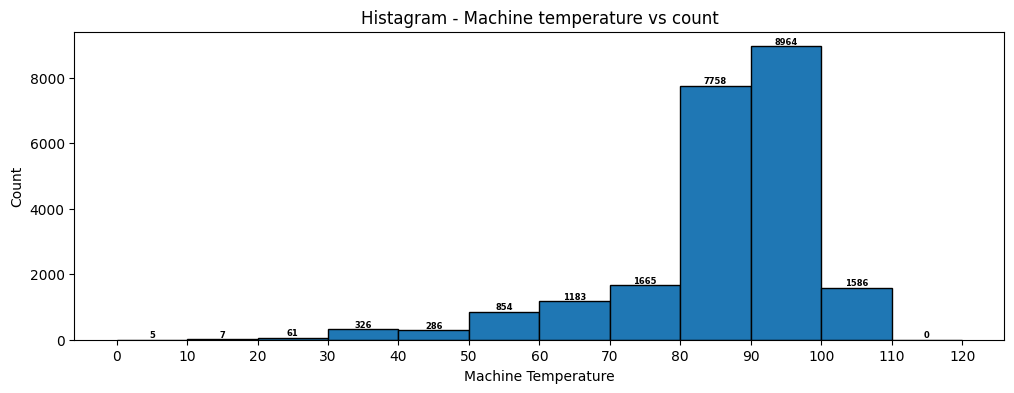

In [12]:
# Histagram
bin_size = range(0, 121, 10)
plt.figure(figsize=(12, 4))
value_count, baredge, bar = plt.hist(df['value'], bins=bin_size, edgecolor='black')

for c, edge, bar_ in zip(value_count, baredge, bar):
    plt.text(
        bar_.get_x() + bar_.get_width() / 2,
        bar_.get_height(),
        int(c),
        ha='center',
        va='bottom',
        fontsize=6,
        fontweight='bold',
        color='black',
    )
plt.xlabel('Machine Temperature')
plt.ylabel('Count')
plt.xticks(bin_size)
plt.title('Histagram - Machine temperature vs count')
plt.show()

In [13]:
fig = px.histogram(df,
                   x='value', 
                   width=1000,
                   height=400,
                   histnorm="probability density",
                   title='Machine Temperature Distribution'
                  )
fig.update_xaxes(tickmode='array',
                 tickvals=list(range(0, 121, 10)),
                )
fig.show()

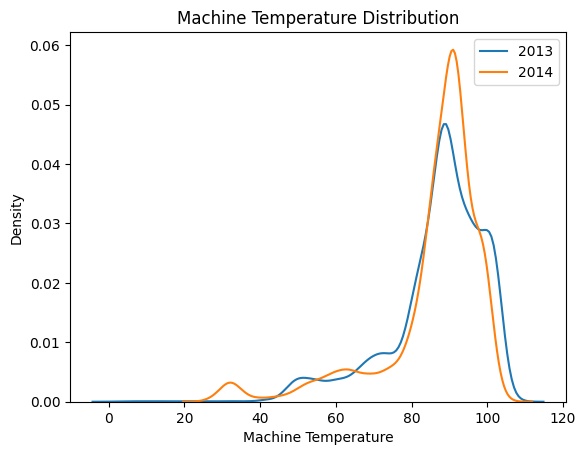

In [14]:
sns.kdeplot(df.loc[df['year']==2013, 'value'], label='2013')
sns.kdeplot(df.loc[df['year']==2014, 'value'], label='2014')

plt.xlabel('Machine Temperature')
plt.legend()
plt.title('Machine Temperature Distribution')
plt.show()

Majority of temperature is around 80~100 degree

### Anomaly Detection

#### XGBoost for classification

#### Function to use
- Temp value vs time
  - Raw temp vs time
  - Training/Validation/Test set visualization
  - Ground truth
  - Rolling properties 
- Confusion matrix
- Actual vs Prediction

#### XGBoost
- Training/Validation/Test data split
- Feature engineering
- XGBoost classifier training
- XGBoost classifier prediction
- XGBoost evaluation

#### Function to use

In [15]:
rolling_properties = [
    'Rolling_mean_one_hour',
    'Rolling_mean_six_hour',
    'Rolling_mean_twelve_hour',
    'Rolling_mean_one_day',
    'Rolling_std_one_hour',
    'Rolling_std_six_hour',
    'Rolling_std_twelve_hour',
    'Rolling_std_one_day',
    'Rolling_slope_one_hour',
    'Rolling_slope_six_hour',
    'Rolling_slope_twelve_hour', 
    'Rolling_slope_one_day'
]

def plot_xgb(df, plot_train_val_test=False, plot_ground_truth=False, plot_rolling=False):
    fig = go.Figure()

    # Plot raw temp vs time
    fig.add_trace(go.Scatter(x=df['time'], 
                             y=df['value'],
                             name='Actual value'
                            )
                 )

    # plot train/validation/test set
    if plot_train_val_test:
        fig.add_trace(go.Scatter(x=df_xgb_train['time'], 
                                 y=df_xgb_train['value'],
                                 # line=dict(color='green'),
                                 name='Training set'
                                )
                     )
        
        fig.add_trace(go.Scatter(x=df_xgb_val['time'], 
                                 y=df_xgb_val['value'],
                                 # line=dict(color='orange'),
                                 name='Validation set'
                                )
                     )
        fig.add_trace(go.Scatter(x=df_xgb_test['time'], 
                                 y=df_xgb_test['value'],
                                 # line=dict(color='orange'),
                                 name='Test set'
                                )
                     )     

    if plot_ground_truth:
        # Plot true anomaly window
        df_boosting_anomaly_window_true = df[df['anomaly_window'] == 1]
        fig.add_trace(go.Scatter(x=df_boosting_anomaly_window_true['time'],
                                 y=df_boosting_anomaly_window_true['value'],
                                 mode='markers',
                                 marker=dict(size=4,color='orange',symbol='circle'),
                                 name='Anomaly window'))
    
        # Plot true anomaly point
        df_boosting_anomaly_true = df[df['anomaly_point'] == 1]
        fig.add_trace(go.Scatter(x=df_boosting_anomaly_true['time'],
                                 y=df_boosting_anomaly_true['value'],
                                 mode='markers',
                                 marker=dict(size=4,color='red',symbol='circle'),
                                 name='Anomaly point'))

    if plot_rolling:
        for rolling in rolling_properties:
            fig.add_trace(go.Scatter(x=df['time'],
                                     y=df[rolling],
                                     name=rolling
                                    )
                         )
    
    fig.update_layout(template='simple_white',
                      font=dict(size=14),
                      xaxis_title='Time',
                      yaxis_title='Temperature',
                      width=1200,
                      height=400,
                      title='XGBoost - Anomaly detection')
    fig.show()

def plot_confusion_matrix(conf_matrix, mode):
    sns.heatmap(conf_matrix,
                cmap='Blues',
                annot=True,
                fmt='d',
                linecolor='white',
                linewidths=0.5
               )
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    if mode in ['Train', 'Validation', 'Test']:
        plt.title(f'Confusion matrix - {mode}', size=10)
    else:
        print('mode parameter should be Train/Validation/Test')
    plt.show()

#### XGBoost - Training/Validation/Test data split
- Training set: 0~60% of data
- Validation set: 60~80% of data 
- Test set: 80~100% of data
- All contain normal and anonmaly

In [16]:
df_xgb_total = df.copy()
split_1 = int(0.6 * df.shape[0])
split_2 = int(0.8 * df.shape[0])
df_xgb_train = df_xgb_total.copy().iloc[:split_1]
df_xgb_val = df_xgb_total.copy().iloc[split_1:split_2]
df_xgb_test = df_xgb_total.copy().iloc[split_2:]

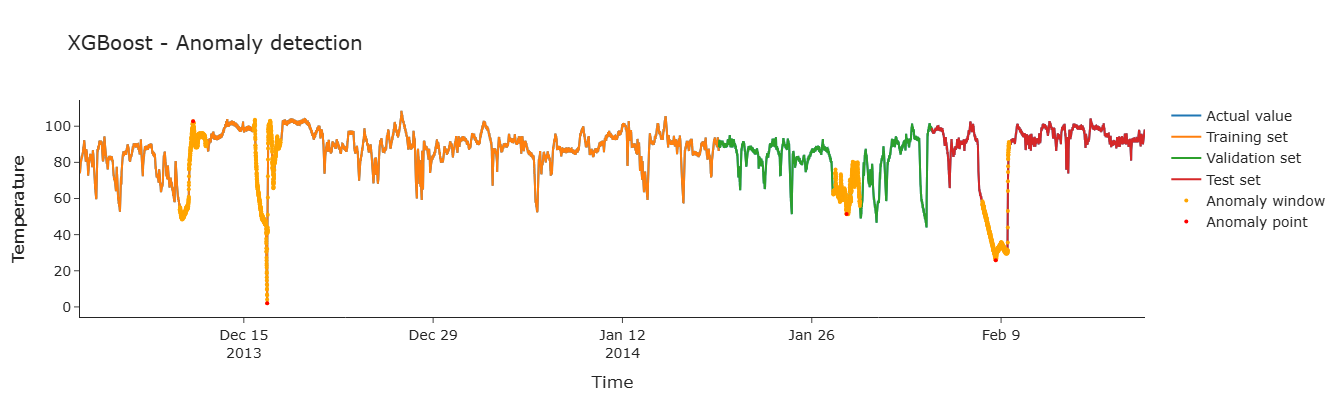

In [17]:
plot_xgb(df=df_xgb_total, plot_train_val_test=True, plot_ground_truth=True, plot_rolling=False)

#### XGBoost - Feature engineering
- Anomaly point is observed around 1 day after normal point

In [18]:
# Window choice (5 mins one point)
one_hour = 12
six_hour = 72
twelve_hour = 144
one_day = 288

windows = {
    'one_hour': 12, 
    'six_hour': 72,
    'twelve_hour': 144, 
    'one_day': 288
          }

df_list = [df_xgb_train, df_xgb_val, df_xgb_test]

# Rolling mean & std
for df in df_list:
    for window in windows:
        df[f'Rolling_mean_{window}'] = df['value'].rolling(windows[window]).mean()

# Rolling std
for df in df_list:
    for window in windows:
        df[f'Rolling_std_{window}'] = df['value'].rolling(windows[window]).std()

# Rolling slope
def slope(y):
    numerator = n * (x * y).sum() - x_sum * y.sum()
    denominator = n * x_square_sum - (x_sum ** 2)
    slope = numerator / denominator
    return slope

for df in df_list:
    for window in windows:
        x = np.arange(1, windows[window]+1)
        x_sum = x.sum()
        x_square_sum = (x ** 2).sum()
        n = len(x)
        df[f'Rolling_slope_{window}'] = df['value'].rolling(windows[window]).apply(slope)

In [19]:
df_xgb_train.columns

Index(['timestamp', 'value', 'time', 'year', 'month', 'day', 'hour', 'minute',
       'anomaly_point', 'anomaly_window', 'Rolling_mean_one_hour',
       'Rolling_mean_six_hour', 'Rolling_mean_twelve_hour',
       'Rolling_mean_one_day', 'Rolling_std_one_hour', 'Rolling_std_six_hour',
       'Rolling_std_twelve_hour', 'Rolling_std_one_day',
       'Rolling_slope_one_hour', 'Rolling_slope_six_hour',
       'Rolling_slope_twelve_hour', 'Rolling_slope_one_day'],
      dtype='object')

In [20]:
df_xgb_test.head()

,timestamp,value,time,year,month,day,hour,minute,anomaly_point,anomaly_window,...,Rolling_mean_twelve_hour,Rolling_mean_one_day,Rolling_std_one_hour,Rolling_std_six_hour,Rolling_std_twelve_hour,Rolling_std_one_day,Rolling_slope_one_hour,Rolling_slope_six_hour,Rolling_slope_twelve_hour,Rolling_slope_one_day
18156,2014-02-03 21:15:00,98.740763,2014-02-03 21:15:00,2014,2,3,21,15,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
18157,2014-02-03 21:20:00,96.882824,2014-02-03 21:20:00,2014,2,3,21,20,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
18158,2014-02-03 21:25:00,98.841761,2014-02-03 21:25:00,2014,2,3,21,25,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
18159,2014-02-03 21:30:00,97.474381,2014-02-03 21:30:00,2014,2,3,21,30,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
18160,2014-02-03 21:35:00,97.492345,2014-02-03 21:35:00,2014,2,3,21,35,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


#### XGBoost - XGBoost classifier training/ Fine tuning
  - Model training: Train model with all features from training set (without shuffle)
  - Build baseline: Use trained model to validate the performance (PR AUC score) with validation set (without shuffle)
  - Permutation importance analysis: Pick feature (one by one) and shuffle the value. Then, validate the performance to see which feature is useless

In [21]:
train_x = df_xgb_train[rolling_properties]
train_y = df_xgb_train['anomaly_window']

val_x = df_xgb_val[rolling_properties]
val_y = df_xgb_val['anomaly_window']

test_x = df_xgb_test[rolling_properties]
test_y = df_xgb_test['anomaly_window']

train_neg = df_xgb_train['anomaly_window'].value_counts()[0]
train_pos = df_xgb_train['anomaly_window'].value_counts()[1]

# Manual compute class weight
scale = train_neg / train_pos

# XGBoost classifier training
xgbclassifier = XGBClassifier(n_estimators=200, learning_rate=0.01, scale_pos_weight=scale, random_state=42)  # XGBClassifier does not have class_weight parameter. It use scale_pos_weight to indicate pos weight compared to neg weight
xgbclassifier.fit(train_x, train_y)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.01, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=200, n_jobs=None,
              num_parallel_tree=None, random_state=42, ...)

PR score: 0.2819
              precision    recall  f1-score   support

           0       0.92      0.90      0.91      3972
           1       0.39      0.45      0.42       567

    accuracy                           0.84      4539
   macro avg       0.66      0.67      0.66      4539
weighted avg       0.85      0.84      0.85      4539



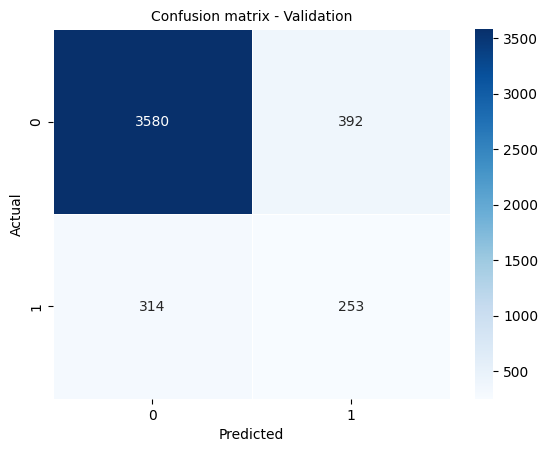

In [23]:
# Build the validation baseline
val_y_proba = xgbclassifier.predict_proba(val_x)
pr_score_val_baseline = average_precision_score(val_y, val_y_proba[:, 1])
print(f'PR score: {pr_score_val_baseline:.4f}')

val_y_pred = xgbclassifier.predict(val_x)
classification_report_xgb = classification_report(val_y, val_y_pred)
print(classification_report_xgb)

conf_xbg_val = confusion_matrix(val_y, val_y_pred)
plot_confusion_matrix(conf_xbg_val, mode='Validation')

In [24]:
# Permutation importance analysis
results = permutation_importance(xgbclassifier, val_x, val_y, n_repeats=10, scoring='average_precision', random_state=42)
for i in range(len(val_x.columns)):
    print(f'Feature: {val_x.columns[i]}')
    print(f'Importance score: {results.importances_mean[i]}')

Feature: Rolling_mean_one_hour
Importance score: -1.6990972478286848e-05
Feature: Rolling_mean_six_hour
Importance score: 0.09964314139543212
Feature: Rolling_mean_twelve_hour
Importance score: 0.0036069660949616276
Feature: Rolling_mean_one_day
Importance score: 0.0339042999520805
Feature: Rolling_std_one_hour
Importance score: 0.0016587479841273177
Feature: Rolling_std_six_hour
Importance score: 0.00043704638832746113
Feature: Rolling_std_twelve_hour
Importance score: -0.009941340390455406
Feature: Rolling_std_one_day
Importance score: -0.04791569329981269
Feature: Rolling_slope_one_hour
Importance score: 0.0006110190647436953
Feature: Rolling_slope_six_hour
Importance score: -0.0001355059879365461
Feature: Rolling_slope_twelve_hour
Importance score: 0.005447174612567463
Feature: Rolling_slope_one_day
Importance score: 0.0034706888916411884


Importances returns the drop between actual score (without shuffle) and score with shuffle.
- Higher positive: parameter is importance
- Almost zero: parameter is useless
- Negative: Parameter is misleading

From the above, we can see the important parameters are
- Rolling_mean_six_hour (~0.09 drop - critical)
- Rolling_mean_one_day (~0.03 drop - critical)
- Rolling_mean_twelve_hour (~0.003 drop - good to have)
- Rolling_slope_twelve_hour (~0.005 drop - good to have)
- Rolling_slope_one_day (~0.003 drop - good to have)  
- Les's modify the used features as above

In [25]:
used_features = ['Rolling_mean_six_hour', 'Rolling_mean_twelve_hour', 'Rolling_mean_one_day', 'Rolling_slope_twelve_hour', 'Rolling_slope_one_day']

# Fine tune model with useful features
train_x_tuned = df_xgb_train[used_features]
train_y = df_xgb_train['anomaly_window']

val_x_tuned = df_xgb_val[used_features]
val_y = df_xgb_val['anomaly_window']

test_x_tuned = df_xgb_test[used_features]
test_y = df_xgb_test['anomaly_window']

train_neg = df_xgb_train['anomaly_window'].value_counts()[0]
train_pos = df_xgb_train['anomaly_window'].value_counts()[1]

# Manual compute class weight
scale = train_neg / train_pos

# XGBoost classifier training
xgbclassifier_tuned = XGBClassifier(n_estimators=200, learning_rate=0.01, scale_pos_weight=scale, random_state=42)  # XGBClassifier does not have class_weight parameter. It use scale_pos_weight to indicate pos weight compared to neg weight
xgbclassifier_tuned.fit(train_x_tuned, train_y)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.01, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=200, n_jobs=None,
              num_parallel_tree=None, random_state=42, ...)

We can see the significant improvement at PR score from 0.28 to 0.51, meaning chosen features makes a good impact on prediction

PR score: 0.5156
              precision    recall  f1-score   support

           0       0.94      0.83      0.88      3972
           1       0.35      0.65      0.46       567

    accuracy                           0.81      4539
   macro avg       0.65      0.74      0.67      4539
weighted avg       0.87      0.81      0.83      4539



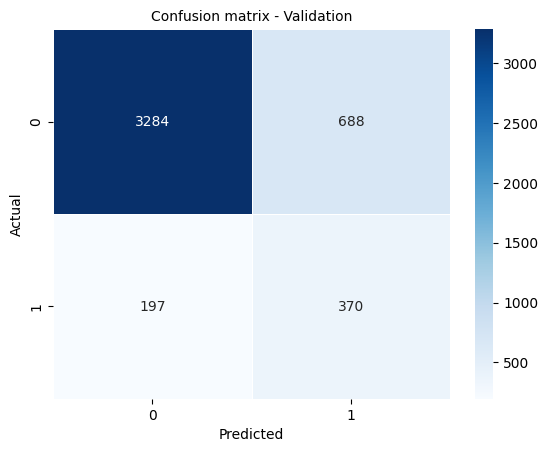

In [31]:
# Validate with validation set
val_y_proba_tuned = xgbclassifier_tuned.predict_proba(val_x_tuned)
pr_score_val_tuned = average_precision_score(val_y, val_y_proba_tuned[:, 1])
print(f'PR score: {pr_score_val_tuned:.4f}')

val_y_pred_tuned = xgbclassifier_tuned.predict(val_x_tuned)
classification_report_xgb_tuned = classification_report(val_y, val_y_pred_tuned)
print(classification_report_xgb_tuned)

conf_xbg_val_tuned = confusion_matrix(val_y, val_y_pred_tuned)
plot_confusion_matrix(conf_xbg_val_tuned, mode='Validation')

In [39]:
val_y_pred_proba[:, 1]

array([0.06756036, 0.06756036, 0.06756036, ..., 0.9148916 , 0.9148916 ,
       0.9148916 ], dtype=float32)

In [40]:
df_ = pd.DataFrame({'Predicted class': list(val_y_pred), 'Predicted probability': list(val_y_pred_proba[:, 1])})
df_

,Predicted class,Predicted probability
0,0,0.067560
1,0,0.067560
2,0,0.067560
3,0,0.067560
4,0,0.067560
...,...,...
4534,1,0.914892
4535,1,0.914892
4536,1,0.914892
4537,1,0.914892


Let's see how the prediction looks compared to ground truth

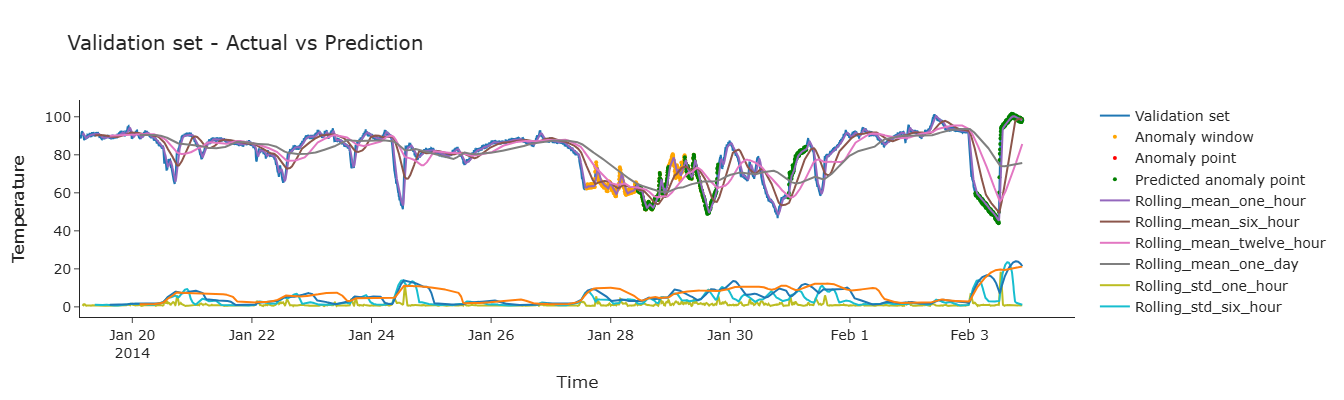

In [25]:
fig = go.Figure()

fig.add_trace(go.Scatter(x=df_xgb_val['time'], 
                         y=df_xgb_val['value'],
                         # line=dict(color='orange'),
                         name='Validation set'
                        )
             )

# Plot true anomaly window
df_anomaly_window_true_val = df_xgb_val[df_xgb_val['anomaly_window'] == 1]
fig.add_trace(go.Scatter(x=df_anomaly_window_true_val['time'],
                         y=df_anomaly_window_true_val['value'],
                         mode='markers',
                         marker=dict(size=4,color='orange',symbol='circle'),
                         name='Anomaly window'))

# Plot true anomaly point
df_anomaly_true_val = df_xgb_val[df_xgb_val['anomaly_point'] == 1]
fig.add_trace(go.Scatter(x=df_anomaly_true_val['time'],
                         y=df_anomaly_true_val['value'],
                         mode='markers',
                         marker=dict(size=4,color='red',symbol='circle'),
                         name='Anomaly point'))

# Plot predicted anomaly points
df_xgb_val['Predicted anomaly'] = val_y_pred
df_xgb_val_pred = df_xgb_val[df_xgb_val['Predicted anomaly']==1]

fig.add_trace(go.Scatter(x=df_xgb_val_pred['time'],
                         y=df_xgb_val_pred['value'],
                         mode='markers',
                         marker=dict(size=4,color='green',symbol='circle'),
                         name='Predicted anomaly point'))

# Plot rolling properties
for rolling in rolling_properties:
    fig.add_trace(go.Scatter(x=df_xgb_val['time'],
                             y=df_xgb_val[rolling],
                             name=rolling
                            )
                 )

fig.update_layout(template='simple_white',
                  font=dict(size=14),
                  xaxis_title='Time',
                  yaxis_title='Temperature',
                  width=1200,
                  height=400,
                  title='Validation set - Actual vs Prediction')
fig.show()

,timestamp,value,time,year,month,day,hour,minute,anomaly_point,anomaly_window,Rolling_mean_one_hour,Rolling_mean_six_hour,Rolling_mean_twelve_hour,Rolling_mean_one_day,Rolling_std_one_hour,Rolling_std_six_hour,Rolling_std_twelve_hour,Rolling_std_one_day
13617,2014-01-19 03:00:00,88.526866,2014-01-19 03:00:00,2014,1,19,3,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
13618,2014-01-19 03:05:00,89.146738,2014-01-19 03:05:00,2014,1,19,3,5,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
13619,2014-01-19 03:10:00,89.506529,2014-01-19 03:10:00,2014,1,19,3,10,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
13620,2014-01-19 03:15:00,90.270867,2014-01-19 03:15:00,2014,1,19,3,15,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
13621,2014-01-19 03:20:00,88.612118,2014-01-19 03:20:00,2014,1,19,3,20,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18151,2014-02-03 20:50:00,97.235514,2014-02-03 20:50:00,2014,2,3,20,50,0,0,98.254640,99.141290,84.359955,75.607728,0.942977,1.146920,22.055084,21.091497
18152,2014-02-03 20:55:00,97.363425,2014-02-03 20:55:00,2014,2,3,20,55,0,0,98.111101,99.128736,84.685833,75.622437,0.936012,1.161476,21.896458,21.105230
18153,2014-02-03 21:00:00,98.963034,2014-02-03 21:00:00,2014,2,3,21,0,0,0,98.052024,99.146768,85.029344,75.639923,0.846649,1.148431,21.727922,21.122528
18154,2014-02-03 21:05:00,98.750927,2014-02-03 21:05:00,2014,2,3,21,5,0,0,98.168603,99.162652,85.374381,75.663979,0.837761,1.134665,21.546569,21.144956


#### XGBoost - XGBoost classifier prediction

#### XGBoost - XGBoost evaluation